In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel, wilcoxon
import matplotlib.pyplot as plt

# načítanie dát
df = pd.read_csv("form.csv")

# výber stĺpcov (celkové hodnotenie)
cols = [
    "Ako celkovo hodnotíte kvalitu tohto prejavu?",
    "Ako celkovo hodnotíte kvalitu tohto prejavu?.1",
    "Ako celkovo hodnotíte kvalitu tohto prejavu?.2",
    "Ako celkovo hodnotíte kvalitu tohto prejavu?.3",
    "Ako celkovo hodnotíte kvalitu tohto prejavu?.4",
    "Ako celkovo hodnotíte kvalitu tohto prejavu?.5"
]

data = df[cols].copy()
data.columns = ["v1", "v2", "v3", "v4", "v5", "v6"]

print("Počet respondentov:", len(data))
data.head()

Počet respondentov: 35


,v1,v2,v3,v4,v5,v6
0,8,6,4,2,5,6
1,8,6,7,5,5,7
2,8,7,9,6,7,8
3,10,9,8,7,8,10
4,7,4,6,3,2,6


In [2]:
normalized = data.copy()

for col in ["v2", "v3", "v4", "v5", "v6"]:
    normalized[col] = data["v1"] - data[col]

normalized.head()

,v1,v2,v3,v4,v5,v6
0,8,2,4,6,3,2
1,8,2,1,3,3,1
2,8,1,-1,2,1,0
3,10,1,2,3,2,0
4,7,3,1,4,5,1


In [3]:
def cohens_d(x, y):
    diff = x - y
    return np.mean(diff) / np.std(diff, ddof=1)

def print_result(name, x, y):
    t_stat, p_t = ttest_rel(x, y)
    w_stat, p_w = wilcoxon(x, y)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Mean X: {np.mean(x):.3f}")
    print(f"Mean Y: {np.mean(y):.3f}")
    print(f"t-test p-value: {p_t:.5f}")
    print(f"Wilcoxon p-value: {p_w:.5f}")
    print(f"Cohen's d: {cohens_d(x, y):.3f}")

In [4]:
nonverbal = normalized[["v2", "v3"]].mean(axis=1)
verbal = normalized[["v4", "v5"]].mean(axis=1)

print_result("H1.1: Neverbálne vs Verbálne", nonverbal, verbal)


H1.1: Neverbálne vs Verbálne
----------------------------------------
Mean X: 1.214
Mean Y: 3.071
t-test p-value: 0.00000
Wilcoxon p-value: 0.00000
Cohen's d: -1.130


In [5]:
print_result("H1.2: Monotónnosť vs Výplňové slová", normalized["v4"], normalized["v5"])


H1.2: Monotónnosť vs Výplňové slová
----------------------------------------
Mean X: 3.171
Mean Y: 2.971
t-test p-value: 0.50651
Wilcoxon p-value: 0.41323
Cohen's d: 0.113


In [6]:
print_result("H2.1: Rozloženie výplňových slov", normalized["v5"], normalized["v6"])


H2.1: Rozloženie výplňových slov
----------------------------------------
Mean X: 2.971
Mean Y: 1.057
t-test p-value: 0.00004
Wilcoxon p-value: 0.00001
Cohen's d: 0.804


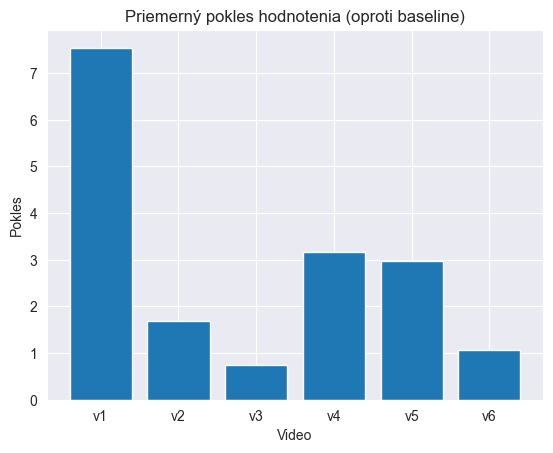

In [7]:
means = normalized.mean()

plt.figure()
plt.bar(means.index, means.values)
plt.title("Priemerný pokles hodnotenia (oproti baseline)")
plt.xlabel("Video")
plt.ylabel("Pokles")
plt.show()

In [8]:
def interpret(p, mean_x, mean_y, hypothesis_type="greater"):
    if p < 0.05:
        if hypothesis_type == "greater":
            return "Hypotéza je podporená." if mean_x > mean_y else "Hypotéza nie je podporená."
        else:
            return "Existuje štatisticky významný rozdiel."
    else:
        return "Rozdiel nie je štatisticky významný."

# H1.1
p = ttest_rel(nonverbal, verbal).pvalue
print("\nH1.1 interpretácia:", interpret(p, np.mean(nonverbal), np.mean(verbal)))

# H1.2
p = ttest_rel(normalized["v4"], normalized["v5"]).pvalue
print("H1.2 interpretácia:", interpret(p, np.mean(normalized["v4"]), np.mean(normalized["v5"])))

# H2.1
p = ttest_rel(normalized["v5"], normalized["v6"]).pvalue
print("H2.1 interpretácia:", "Hypotéza podporená." if p > 0.05 else "Hypotéza zamietnutá.")


H1.1 interpretácia: Hypotéza nie je podporená.
H1.2 interpretácia: Rozdiel nie je štatisticky významný.
H2.1 interpretácia: Hypotéza zamietnutá.
